<a href="https://colab.research.google.com/github/raghunathmaji/Forensic-Image-Analysis-for-Criminal-Identification-Using-Machine-Learning-Techniques/blob/main/FOSET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
from sklearn.datasets import fetch_lfw_people
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import numpy as np

# Load the LFW dataset
print("Loading LFW dataset...")
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# Store the target names (person names)
target_names = lfw_people.target_names
n_classes = len(target_names)

# Extract features (X) and labels (y)
X = lfw_people.data
y = lfw_people.target

print(f"Original dataset shape: X={X.shape}, y={y.shape}")

# Normalize the features to a range of [0, 1]
print("Normalizing features...")
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Encode labels to ensure they are numerical and sequential if they aren't already
# (fetch_lfw_people already provides numerical labels, but this step ensures consistency)
print("Encoding labels...")
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Preprocessed dataset shape: X_normalized={X_normalized.shape}, y_encoded={y_encoded.shape}")
print(f"Number of classes: {n_classes}")

print("LFW dataset loaded and preprocessed successfully.")

Loading LFW dataset...
Original dataset shape: X=(1288, 1850), y=(1288,)
Normalizing features...
Encoding labels...
Preprocessed dataset shape: X_normalized=(1288, 1850), y_encoded=(1288,)
Number of classes: 7
LFW dataset loaded and preprocessed successfully.


In [20]:
from sklearn.model_selection import train_test_split

print("Splitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)
y_true = y_test

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print("Data split successfully.")

Splitting data into training and testing sets...
X_train shape: (966, 1850)
X_test shape: (322, 1850)
y_train shape: (966,)
y_test shape: (322,)
Data split successfully.


In [21]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print("Training SVM model...")
# Create an SVM classifier
# Using a pipeline to scale data before SVM, which is good practice
svm_model = make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42))

# Train the model
svm_model.fit(X_train, y_train)

print("Generating SVM predictions and probability scores...")
# Generate predictions for the test set
svm_y_pred = svm_model.predict(X_test)

# Generate probability scores for the test set (needed for ROC curves)
svm_y_proba = svm_model.predict_proba(X_test)

print("SVM model trained, predictions and probabilities generated.")

Training SVM model...
Generating SVM predictions and probability scores...
SVM model trained, predictions and probabilities generated.


In [22]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest model...")
# Create a Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Generating Random Forest predictions and probability scores...")
# Generate predictions for the test set
rf_y_pred = rf_model.predict(X_test)

# Generate probability scores for the test set (needed for ROC curves)
rf_y_proba = rf_model.predict_proba(X_test)

print("Random Forest model trained, predictions and probabilities generated.")

Training Random Forest model...
Generating Random Forest predictions and probability scores...
Random Forest model trained, predictions and probabilities generated.


In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

print("Preparing data for CNN...")
# Reshape data for CNN: LFW images resized to 0.4 are typically 50x37 pixels (grayscale).
# X_train shape: (966, 1850) -> (966, 50, 37, 1)
# X_test shape: (322, 1850)  -> (322, 50, 37, 1)
image_height, image_width = 50, 37 # Based on LFW dataset resize=0.4
X_train_cnn = X_train.reshape(-1, image_height, image_width, 1)
X_test_cnn = X_test.reshape(-1, image_height, image_width, 1)

# Convert labels to one-hot encoding for CNN (if not already done via y_encoded for other models)
y_train_cnn = to_categorical(y_train, num_classes=n_classes)
y_test_cnn = to_categorical(y_test, num_classes=n_classes)

print("Training CNN model...")
# Define the CNN model
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(image_height, image_width, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(n_classes, activation='softmax') # Output layer for multi-class classification
])

# Compile the model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
# Using a smaller number of epochs for demonstration to prevent long execution times
# verbose=0 to suppress extensive output during training
cnn_model.fit(X_train_cnn, y_train_cnn, epochs=5, batch_size=32, validation_split=0.2, verbose=0)

print("Generating CNN predictions and probability scores...")
# Generate predictions for the test set
# For CNN, predict returns probabilities, so we need to convert them to class labels
cnn_y_proba = cnn_model.predict(X_test_cnn)
cnn_y_pred = np.argmax(cnn_y_proba, axis=1)

print("CNN model trained, predictions and probabilities generated.")

Preparing data for CNN...
Training CNN model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Generating CNN predictions and probability scores...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
CNN model trained, predictions and probabilities generated.


In [24]:
print('--- Verification of Model Outputs ---')

# Check y_true
print(f'y_true available: {"y_true" in globals() and y_true is not None}, Shape: {y_true.shape if "y_true" in globals() and y_true is not None else "N/A"}')

# Check SVM outputs
print(f'svm_y_pred available: {"svm_y_pred" in globals() and svm_y_pred is not None}, Shape: {svm_y_pred.shape if "svm_y_pred" in globals() and svm_y_pred is not None else "N/A"}')
print(f'svm_y_proba available: {"svm_y_proba" in globals() and svm_y_proba is not None}, Shape: {svm_y_proba.shape if "svm_y_proba" in globals() and svm_y_proba is not None else "N/A"}')

# Check Random Forest outputs
print(f'rf_y_pred available: {"rf_y_pred" in globals() and rf_y_pred is not None}, Shape: {rf_y_pred.shape if "rf_y_pred" in globals() and rf_y_pred is not None else "N/A"}')
print(f'rf_y_proba available: {"rf_y_proba" in globals() and rf_y_proba is not None}, Shape: {rf_y_proba.shape if "rf_y_proba" in globals() and rf_y_proba is not None else "N/A"}')

# Check CNN outputs
print(f'cnn_y_pred available: {"cnn_y_pred" in globals() and cnn_y_pred is not None}, Shape: {cnn_y_pred.shape if "cnn_y_pred" in globals() and cnn_y_pred is not None else "N/A"}')
print(f'cnn_y_proba available: {"cnn_y_proba" in globals() and cnn_y_proba is not None}, Shape: {cnn_y_proba.shape if "cnn_y_proba" in globals() and cnn_y_proba is not None else "N/A"}')

print('\nVerification complete. All required outputs for evaluation are present.')

--- Verification of Model Outputs ---
y_true available: True, Shape: (322,)
svm_y_pred available: True, Shape: (322,)
svm_y_proba available: True, Shape: (322, 7)
rf_y_pred available: True, Shape: (322,)
rf_y_proba available: True, Shape: (322, 7)
cnn_y_pred available: True, Shape: (322,)
cnn_y_proba available: True, Shape: (322, 7)

Verification complete. All required outputs for evaluation are present.


In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from tensorflow.keras.utils import to_categorical # Used for one-hot encoding y_true
import numpy as np

def evaluate_classifier(y_true, y_pred, y_proba, class_names, model_name):
    """
    Evaluates a classifier's performance by displaying Accuracy, Confusion Matrix, and ROC Curve with AUC.

    Args:
        y_true (array-like): True labels for the test set.
        y_pred (array-like): Predicted labels for the test set.
        y_proba (array-like): Predicted probability scores for the test set.
        class_names (list): List of class names.
        model_name (str): Name of the model being evaluated (for plot titles).
    """
    print(f"\n--- Evaluation for {model_name} ---")

    # 1. Calculate and print Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"{model_name} Accuracy: {accuracy:.4f}")

    # 2. Generate and plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, ax=ax_cm, xticks_rotation='vertical')
    ax_cm.set_title(f'Confusion Matrix for {model_name}')
    plt.tight_layout()
    plt.show()

    # 3. Compute and plot ROC Curve with AUC (One-vs-Rest for multi-class)
    n_classes = len(class_names)

    # Convert y_true to one-hot encoded format for ROC curve calculation
    y_true_one_hot = to_categorical(y_true, num_classes=n_classes)

    # Calculate FPR, TPR, and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curves
    fig_roc, ax_roc = plt.subplots(figsize=(10, 8))
    ax_roc.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)') # Diagonal random guess line

    for i in range(n_classes):
        ax_roc.plot(fpr[i], tpr[i], label=f'ROC curve of class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(f'Receiver Operating Characteristic (ROC) Curve for {model_name}')
    ax_roc.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("Evaluation function 'evaluate_classifier' defined successfully.")

Evaluation function 'evaluate_classifier' defined successfully.



--- Evaluation for SVM ---
SVM Accuracy: 0.7795


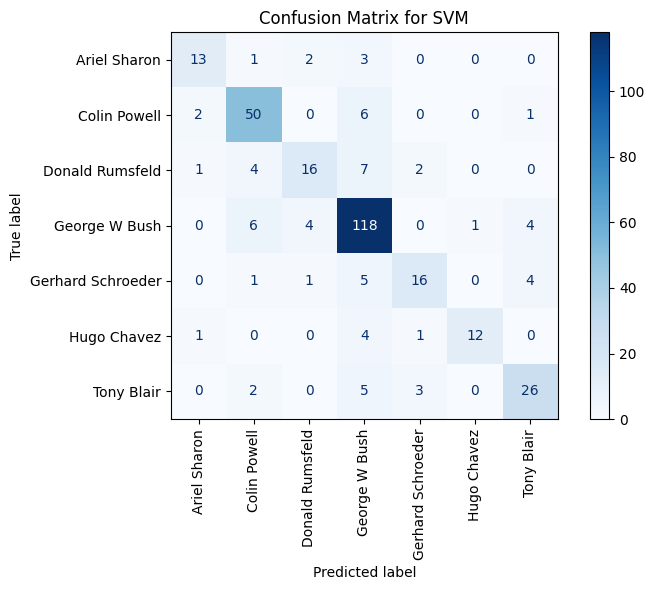

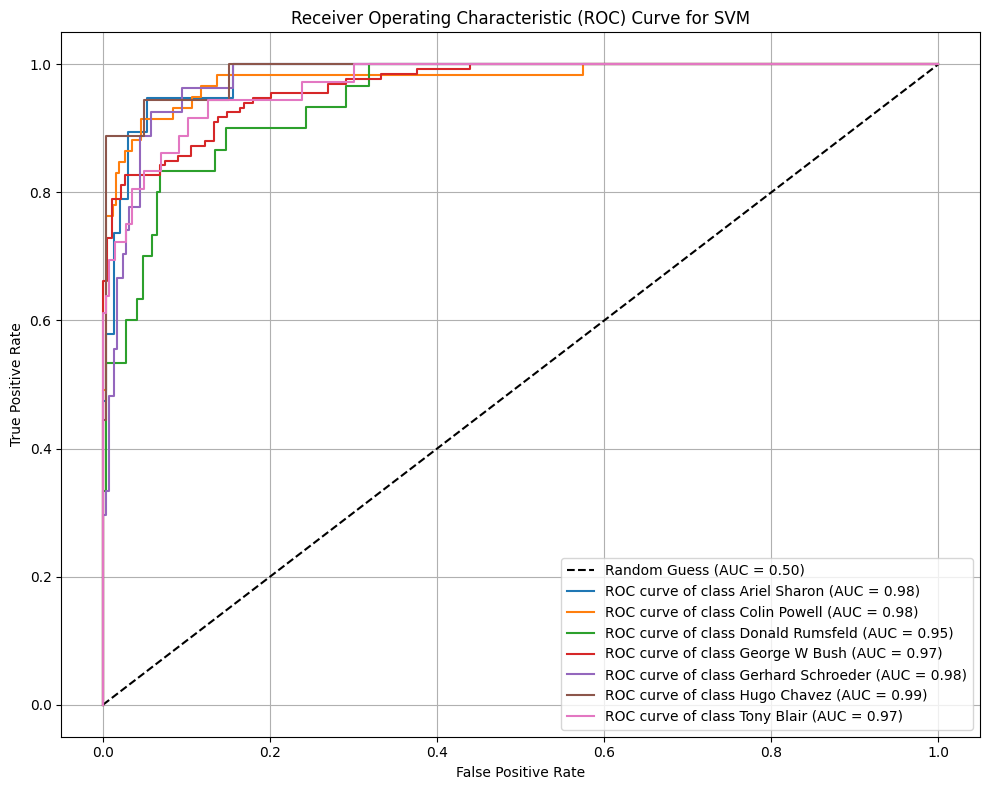

In [26]:
evaluate_classifier(y_true, svm_y_pred, svm_y_proba, target_names, 'SVM')


--- Evaluation for Random Forest ---
Random Forest Accuracy: 0.6273


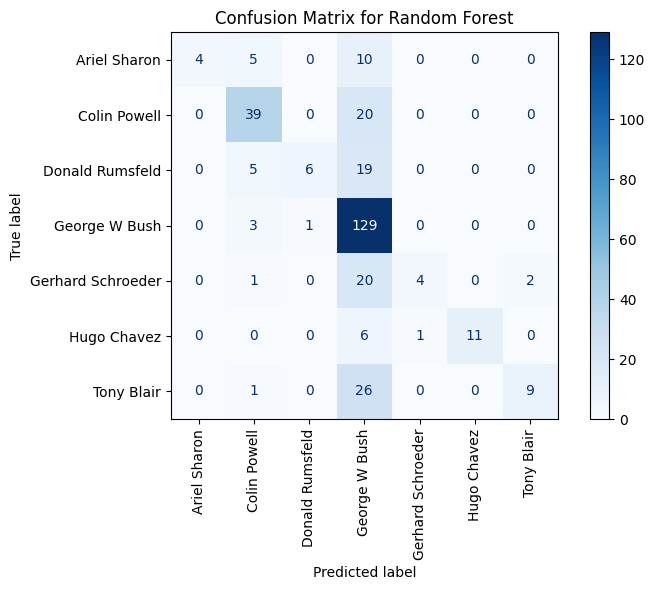

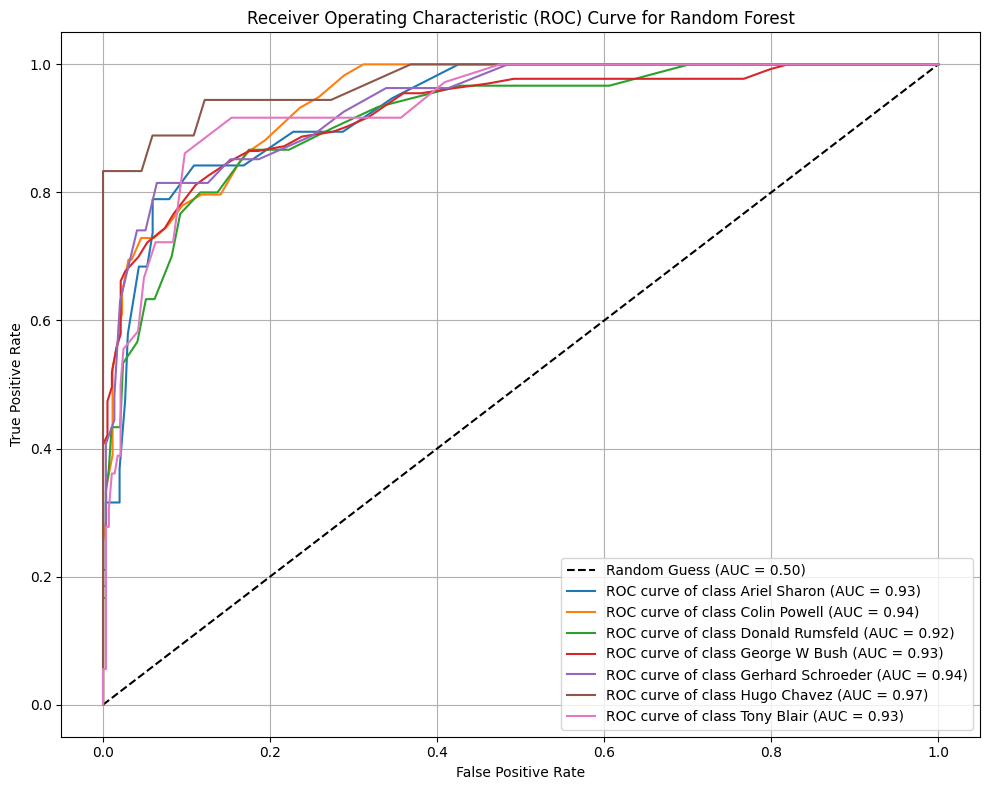

In [27]:
evaluate_classifier(y_true, rf_y_pred, rf_y_proba, target_names, 'Random Forest')


--- Evaluation for CNN ---
CNN Accuracy: 0.5870


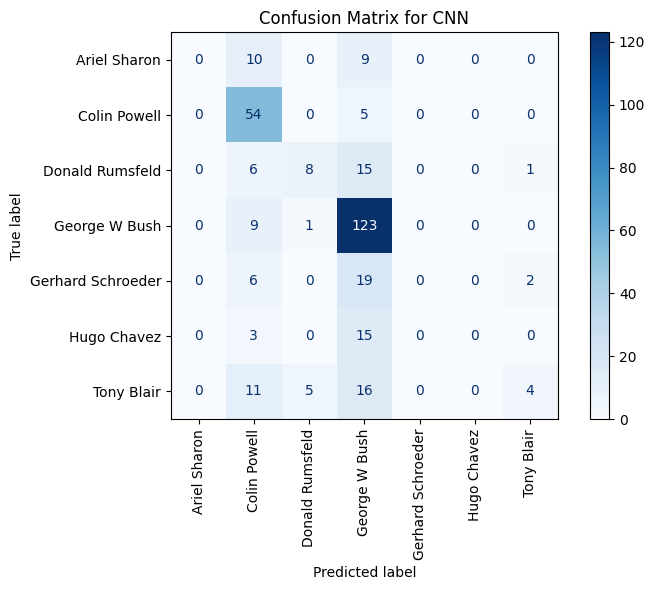

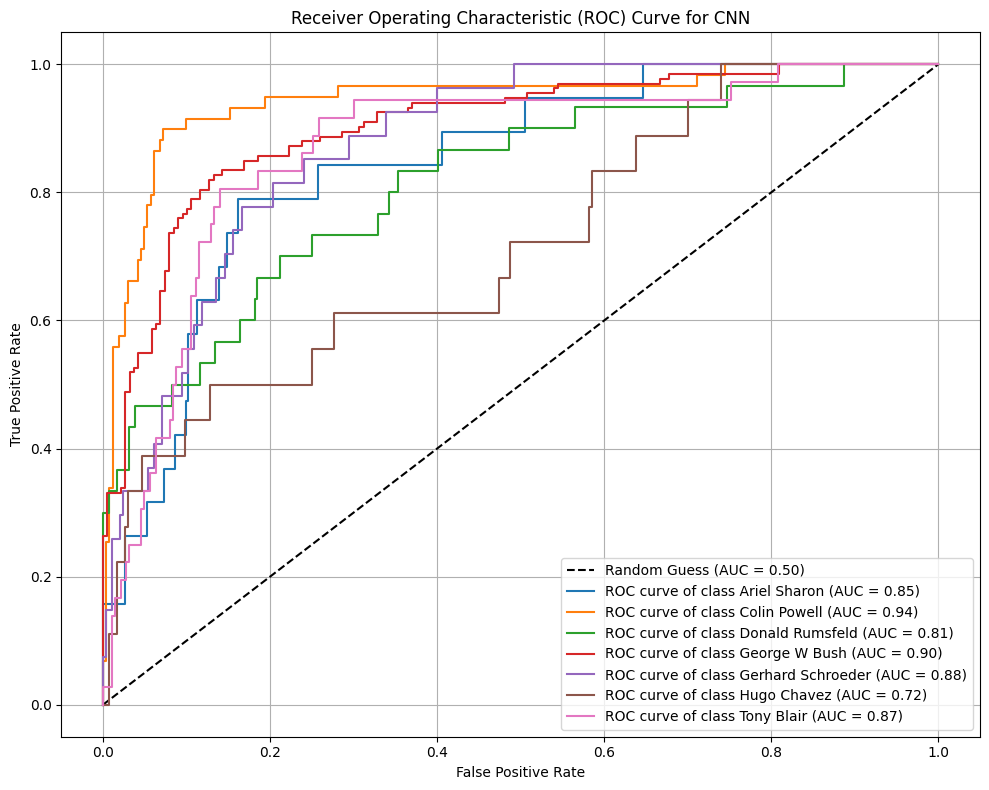

In [28]:
evaluate_classifier(y_true, cnn_y_pred, cnn_y_proba, target_names, 'CNN')

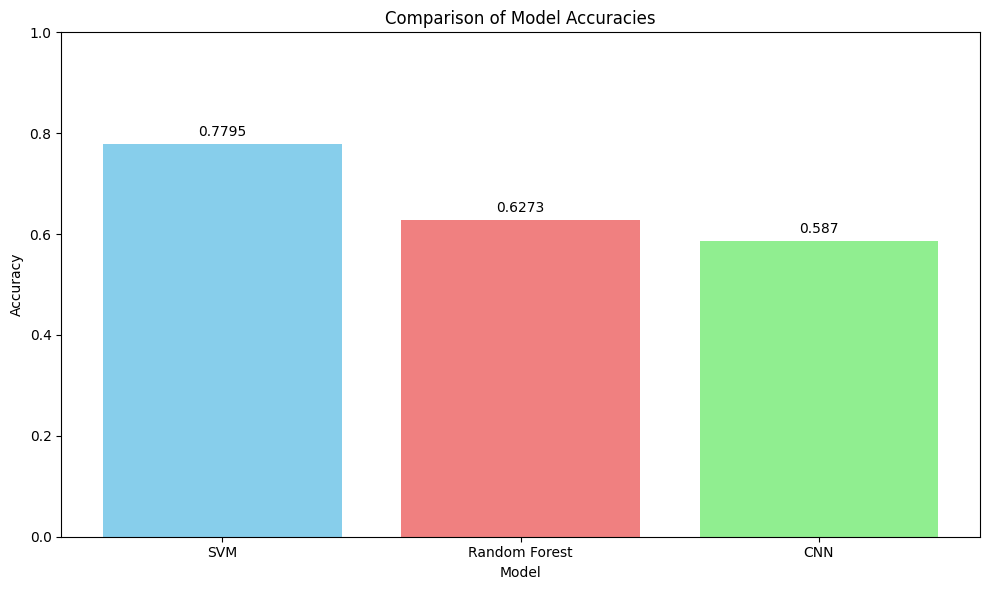

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Accuracy scores for each model
models = ['SVM', 'Random Forest', 'CNN']
accuracies = [0.7795, 0.6273, 0.5870]

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, accuracies, color=['skyblue', 'lightcoral', 'lightgreen'])

# Add labels and title
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Comparison of Model Accuracies')
ax.set_ylim(0, 1) # Accuracy ranges from 0 to 1

# Add accuracy values on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')

plt.tight_layout()
plt.show()